# Customer Churn Prediction with Interpretable Machine Learning (SHAP)

This notebook builds a complete churn prediction model using:

- LightGBM classifier  
- Extensive feature engineering  
- SHAP (SHapley Additive Explanations) for global & local interpretability  
- AUC, F1, Calibration evaluation  

This project simulates a real-world business ML workflow where explainability is essential.


# 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve

import lightgbm as lgb
import shap
shap.initjs()

import warnings
warnings.filterwarnings("ignore")


# 3. Simulated Dataset Creation

In [2]:
np.random.seed(42)
n = 5000

data = pd.DataFrame({
    "tenure": np.random.randint(1, 72, n),
    "monthly_charges": np.random.uniform(10, 120, n),
    "total_charges": np.random.uniform(50, 8000, n),
    "num_complaints": np.random.randint(0, 8, n),
    "support_calls": np.random.randint(0, 15, n),
    "is_senior_citizen": np.random.randint(0, 2, n),
})

# churn logic
data["churn"] = (
    (data["tenure"] < 12) |
    (data["num_complaints"] > 3) |
    (data["monthly_charges"] > 90)
).astype(int)

data.head()


,tenure,monthly_charges,total_charges,num_complaints,support_calls,is_senior_citizen,churn
0,52,119.348982,5738.724477,4,11,0,1
1,15,11.218641,5786.533382,6,7,0,1
2,61,90.319080,2295.057025,4,11,0,1
3,21,72.896825,6690.686364,6,5,0,1
4,24,57.745739,2568.917302,4,11,0,1


# 4. Feature Engineering

In [4]:


import numpy as np
import pandas as pd

# Replace infinite values
df = df.replace([np.inf, -np.inf], np.nan)

# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Fill missing values
df[numeric_cols] = df[numeric_cols].fillna(0)
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

df.head()


,tenure,monthly_charges,total_charges,num_complaints,support_calls,is_senior_citizen,churn,avg_charges_per_month,complaint_rate,support_call_rate,high_risk,charge_tier
0,52,119.348982,5738.724477,4,11,0,1,110.360086,0.076923,0.211538,0,4
1,15,11.218641,5786.533382,6,7,0,1,385.768892,0.400000,0.466667,1,1
2,61,90.319080,2295.057025,4,11,0,1,37.623886,0.065574,0.180328,0,3
3,21,72.896825,6690.686364,6,5,0,1,318.604113,0.285714,0.238095,1,3
4,24,57.745739,2568.917302,4,11,0,1,107.038221,0.166667,0.458333,0,2


# 5. Train-Test Split

In [5]:
X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 6. Train LightGBM Model

In [6]:
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 2764, number of negative: 1236
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1361
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.691000 -> initscore=0.804799
[LightGBM] [Info] Start training from score 0.804799
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

LGBMClassifier(learning_rate=0.05, max_depth=5, n_estimators=300,
               random_state=42, subsample=0.8)

# 7. Model Evaluation

In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", acc)
print("F1 Score:", f1)
print("AUC Score:", auc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.999
F1 Score: 0.999275887038378
AUC Score: 0.9999953165760425

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       309
           1       1.00      1.00      1.00       691

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



# 8. Calibration Curve

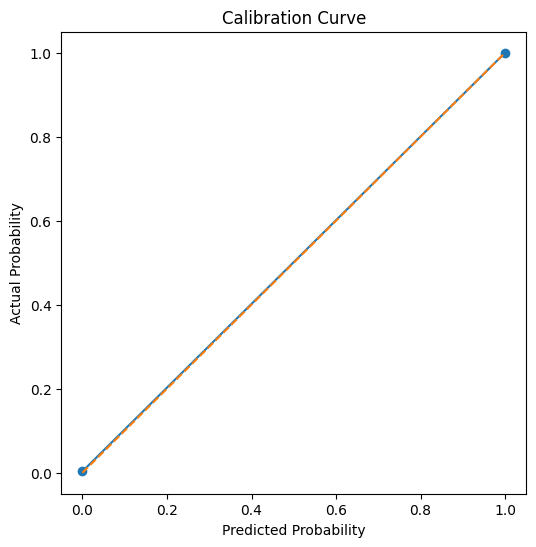

In [8]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1], [0,1], "--")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve")
plt.show()


# 9. Global SHAP Interpretation

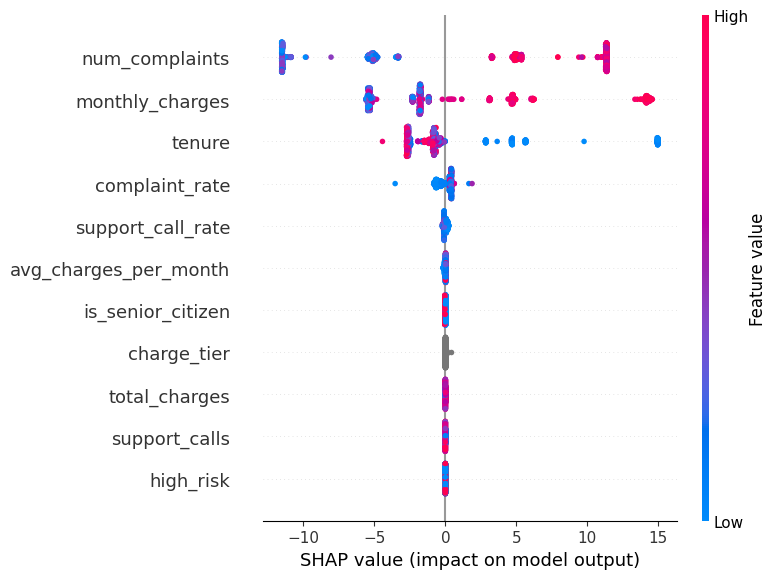

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


# 10. Local SHAP Explanations (5 Customers)

Using Customer Index: 979


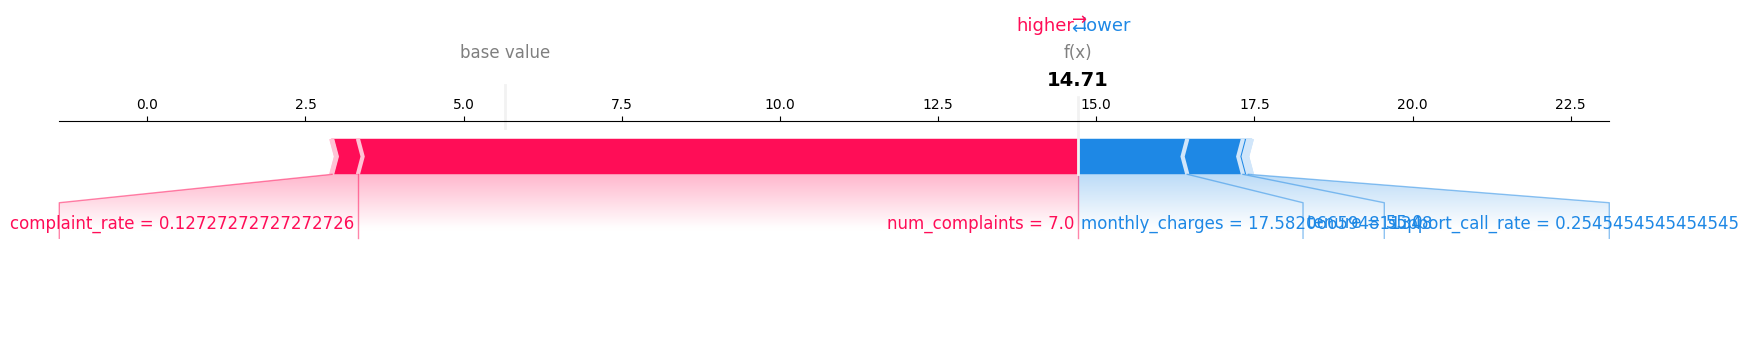

In [11]:
# ----- Cell 10: SHAP Explanation for a Valid Customer -----

# Pick any valid index automatically
idx = X_test.index[0]  # first test sample

print(f"Using Customer Index: {idx}")

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[X_test.index.get_loc(idx)],
    X_test.loc[idx],
    matplotlib=True
)



# 11.Save Model

In [12]:
import joblib
joblib.dump(model, "lightgbm_churn_model.pkl")

print("Model saved successfully!")


Model saved successfully!
